# Exploratory Data Analysis (EDA) — PdM_telemetry.csv

# 1 ) Introduction
## 1.1 AI-Based Predictive Maintenance System

Dataset

Microsoft Azure Predictive Maintenance Dataset

Goal

To understand machine operational behavior, sensor patterns, machine health indicators, anomalies, and operational trends before building machine learning models for machine failure prediction and predictive maintenance.

## 1.2 Dataset Feature Description

datetime   : Timestamp of machine reading

machineID  : Unique machine identifier

volt       : Voltage reading

rotate     : Rotational speed

pressure   : Pressure reading

vibration  : Vibration reading


## 1.3 Business Objective

The objective of this analysis is to understand machine operational behavior using telemetry sensor data and identify patterns that may indicate potential machine failures. The analysis focuses on sensor performance, machine stability, anomaly detection, and time-based operational trends. The insights obtained will support predictive maintenance strategies and improve machine reliability, operational efficiency, and downtime reduction.

# 2 ) Data Understanding

## 2.1 Import Libraries

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2.2 Load Dataset

In [ ]:
# Load Telemetry Dataset

telemetry = pd.read_csv("PdM_telemetry.csv")

# First 5 rows
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


*  Dataset successfully loaded.
*  Each record represents machine sensor readings at a specific timestamp.
* Sensor variables include voltage, rotation, pressure, and vibration measurements.



## 2.3 Basic Dataset Information

In [ ]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


* Dataset contains sensor measurements from multiple machines.
* Numerical and datetime features are present.
* Dataset is suitable for time-series and predictive maintenance analysis.

## 2.4 Dataset Shape

In [ ]:
print("Dataset Shape :", telemetry.shape)

print("Rows :", telemetry.shape[0])

print("Columns :", telemetry.shape[1])

Dataset Shape : (876100, 6)
Rows : 876100
Columns : 6


## 2.5 Statistical Summary of Numerical Features

In [ ]:
telemetry.describe()

,machineID,volt,rotate,pressure,vibration
count,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,50.500000,170.777736,446.605119,100.858668,40.385007
std,28.866087,15.509114,52.673886,11.048679,5.370361
min,1.000000,97.333604,138.432075,51.237106,14.877054
25%,25.750000,160.304927,412.305714,93.498181,36.777299
50%,50.500000,170.607338,447.558150,100.425559,40.237247
75%,75.250000,181.004493,482.176600,107.555231,43.784938
max,100.000000,255.124717,695.020984,185.951998,76.791072


* Voltage, pressure, rotation, and vibration show varying operating ranges.
* Presence of extreme values may indicate abnormal machine behavior.
* Statistical variation suggests different machine operating conditions.


# 3 ) Missing Value Analysis

## 3.1 Missing Values

In [ ]:
telemetry.isnull().sum()

,0
datetime,0
machineID,0
volt,0
rotate,0
pressure,0
vibration,0


* No significant missing values are observed.
* Dataset quality is high and requires minimal missing-value treatment.

## 3.2 Missing Value Percentage

In [ ]:
missing_percentage = (telemetry.isnull().sum()/len(telemetry))*100

missing_percentage

,0
datetime,0.0
machineID,0.0
volt,0.0
rotate,0.0
pressure,0.0
vibration,0.0


* Missing percentage is negligible across all features.
* Dataset can be used directly for further analysis.

# 4 ) Duplicate Analysis

## 4.1 Duplicate Records Analysis

In [ ]:
duplicates = telemetry.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


# 5 ) Sensor Distribution Analysis

## 5.1 Voltage Distribution
 objective
* To analyze the voltage behavior of machines and identify electrical operating patterns.

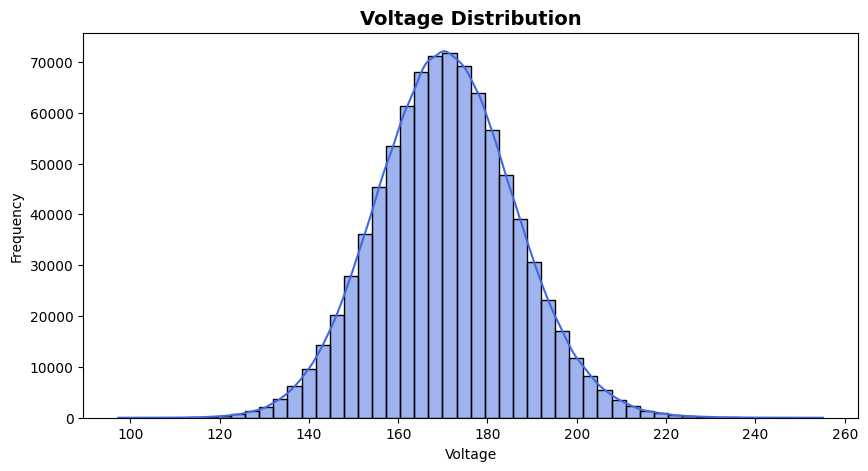

In [ ]:
# Voltage Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    telemetry['volt'],
    bins=50,
    kde=True,
    color='royalblue'
)

plt.title(
    "Voltage Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Voltage")

plt.ylabel("Frequency")

plt.show()

* Voltage values are concentrated within a stable operating range.
* The distribution appears approximately normal.
* Extreme voltage fluctuations may indicate electrical issues.

## 6.2 Rotation Distribution
Objective

* To understand machine rotational speed behavior.

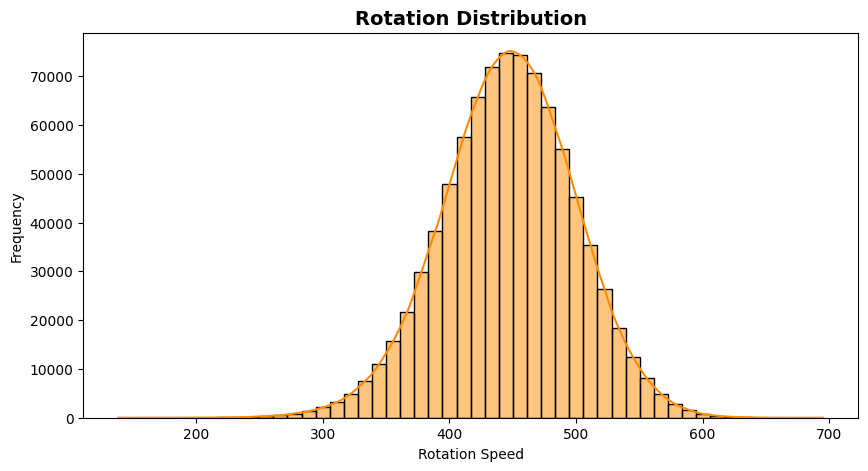

In [ ]:
# Rotation Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    telemetry['rotate'],
    bins=50,
    kde=True,
    color='darkorange'
)

plt.title(
    "Rotation Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Rotation Speed")

plt.ylabel("Frequency")

plt.show()

* Rotation speed shows operational variability.
* Most readings fall within normal  machine operating limits.
* Few extreme rotation values are observed.
* Rotation speed reflects machine workload.
* Sudden speed changes may indicate mechanical issues.
* Rotation is an important predictor of machine condition.

## 6.3 Pressure Distribution
Objective

To analyze pressure readings and identify abnormal pressure behavior.

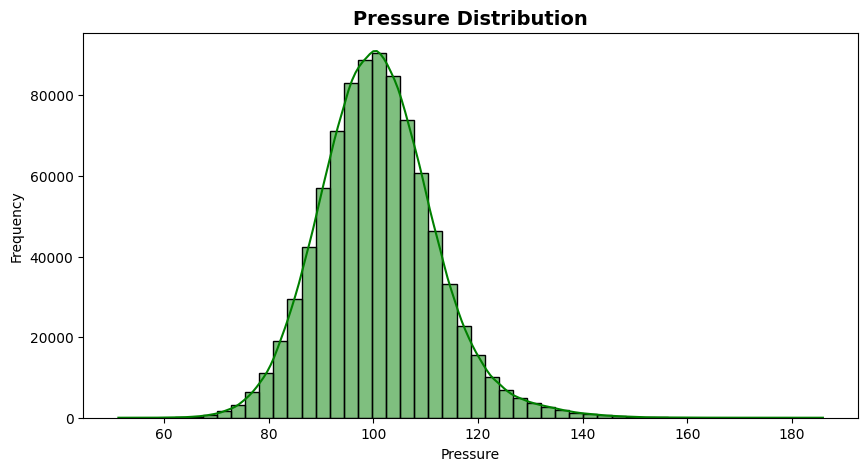

In [ ]:
# Pressure Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    telemetry['pressure'],
    bins=50,
    kde=True,
    color='green'
)

plt.title(
    "Pressure Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Pressure")

plt.ylabel("Frequency")

plt.show()

* Pressure values are distributed around a normal operating range.
* Some high-pressure readings are visible.
* Distribution indicates varying operational loads.

## 6.4 Vibration Distribution
Objective

To analyze machine vibration patterns.

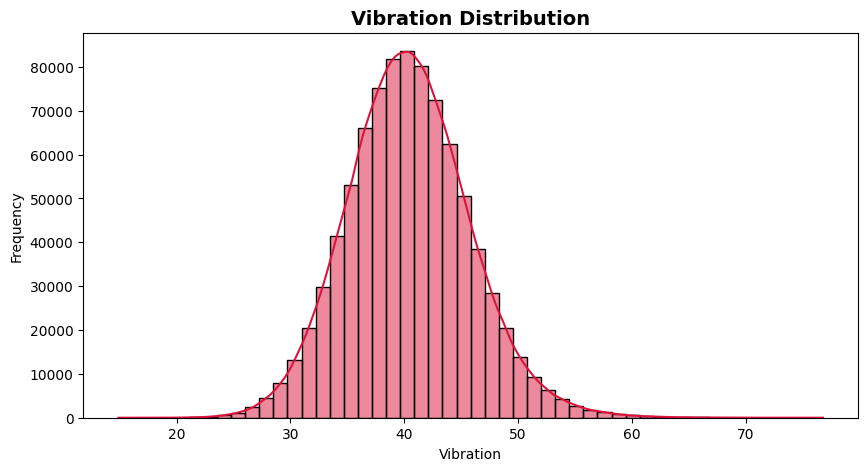

In [ ]:
# Vibration Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    telemetry['vibration'],
    bins=50,
    kde=True,
    color='crimson'
)

plt.title(
    "Vibration Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Vibration")

plt.ylabel("Frequency")

plt.show()

* Vibration values show noticeable variation.
* Several high vibration readings are present.
* Distribution may contain abnormal operating conditions.

# 7 ) Outlier Analysis

## 7.1 Voltage Outlier Analysis
Objective

To detect abnormal voltage observations.

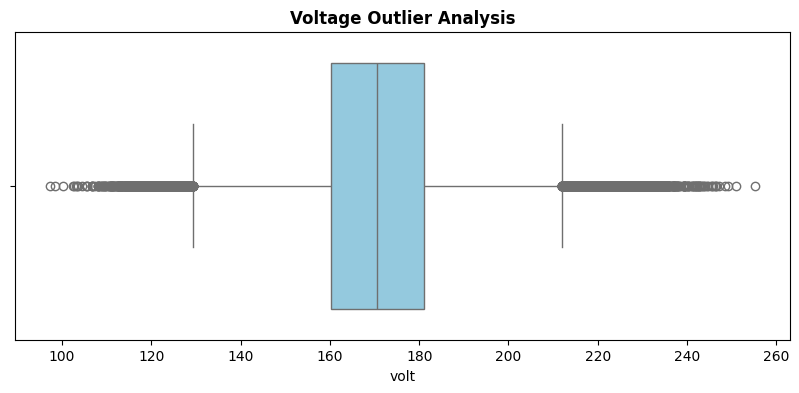

In [ ]:
# Voltage Outlier Analysis

plt.figure(figsize=(10,4))

sns.boxplot(
    x=telemetry['volt'],
    color='skyblue'
)

plt.title(
    "Voltage Outlier Analysis",
    fontweight='bold'
)

plt.show()

* Several voltage outliers are detected.
* Most values remain within the interquartile range.
* Outliers may represent electrical instability.
* These records should be investigated before modeling.

# 8 ) Machine-wise Analysis
## 8.1 Top 10 Machines by Average Voltage

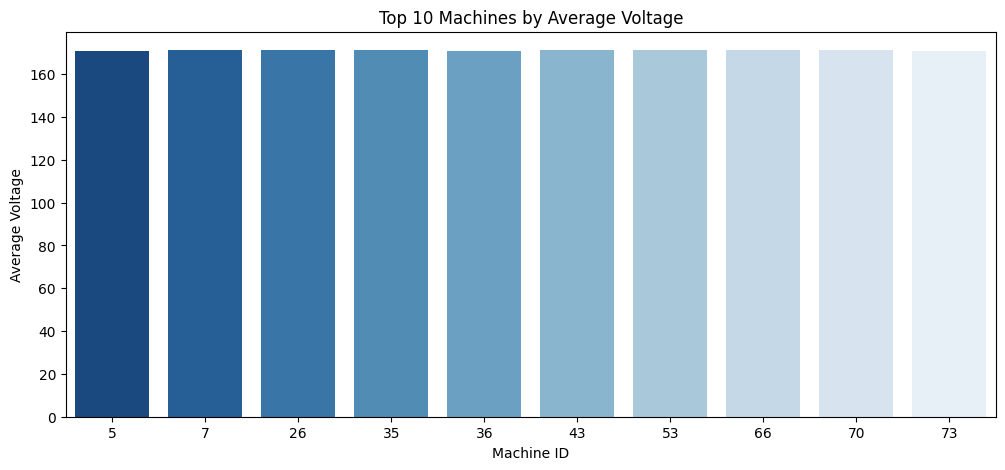

In [ ]:
# Top Machines by Average Voltage

top_voltage = (
    telemetry.groupby('machineID')['volt']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_voltage.index,
    y=top_voltage.values,
    palette='Blues_r'
)

plt.title('Top 10 Machines by Average Voltage')

plt.xlabel('Machine ID')

plt.ylabel('Average Voltage')

plt.show()

* Certain machines consistently operate at higher voltage levels.
* Voltage consumption varies across machines.
* A small group of machines shows unusually high average voltage.
* High-voltage machines may experience greater electrical stress.
* These machines should be monitored more frequently.

## 8.2 Top 10 Machines by Average Pressure

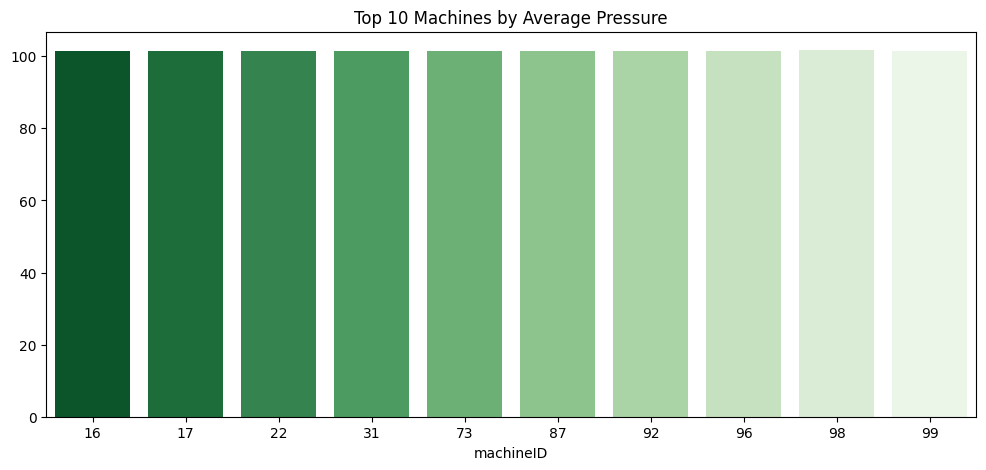

In [ ]:
top_pressure = (
    telemetry.groupby('machineID')['pressure']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_pressure.index,
    y=top_pressure.values,
    palette='Greens_r'
)

plt.title('Top 10 Machines by Average Pressure')

plt.show()

* Pressure distribution differs among machines.
* Some machines operate under significantly higher pressure.
* Machines with higher pressure are more susceptible to wear and tear.
* Pressure monitoring can help prevent overload failures.

## 8.3 Top 10 Machines by Average Vibration

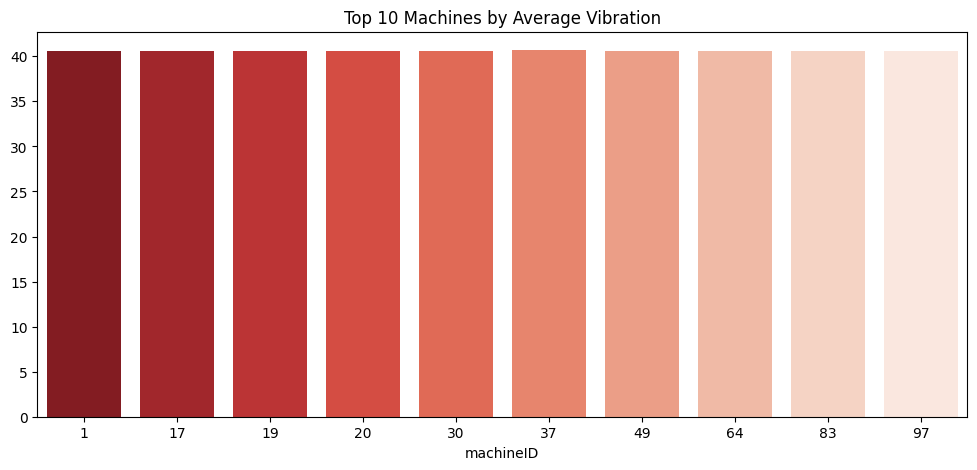

In [ ]:
top_vibration = (
    telemetry.groupby('machineID')['vibration']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_vibration.index,
    y=top_vibration.values,
    palette='Reds_r'
)

plt.title('Top 10 Machines by Average Vibration')

plt.show()

* Several machines exhibit higher vibration levels.
* Vibration variability suggests differences in machine health.
* High vibration is often associated with component degradation.
* These machines can be considered potential failure candidates.

## 8.4 Top 10 Machines by Average Rotation

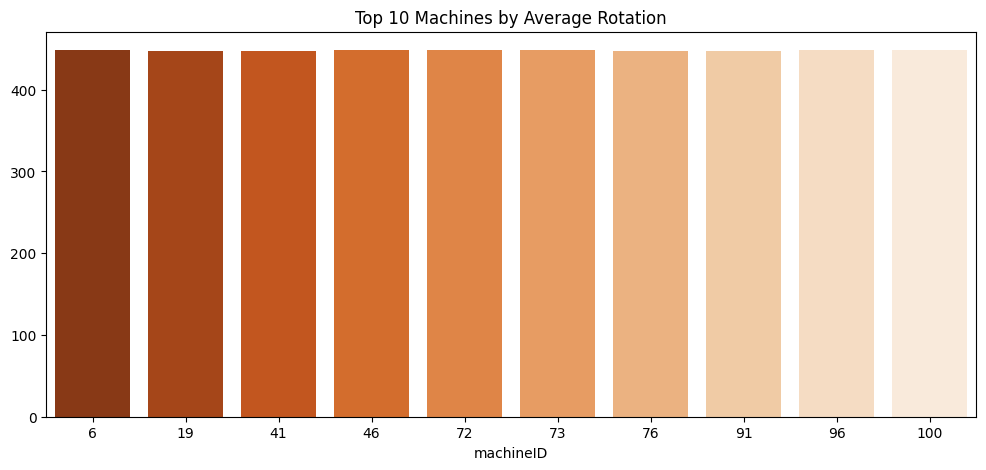

In [ ]:
top_rotate = (
    telemetry.groupby('machineID')['rotate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_rotate.index,
    y=top_rotate.values,
    palette='Oranges_r'
)

plt.title('Top 10 Machines by Average Rotation')

plt.show()

* Rotation speed varies significantly among machines.
* Some machines handle heavier workloads than others.
* High rotation machines may experience faster component wear.
* Rotation speed can be used as a machine utilization indicator.

# 9 ) Sensor Relationship Analysis
## 9.1 Voltage vs Pressure

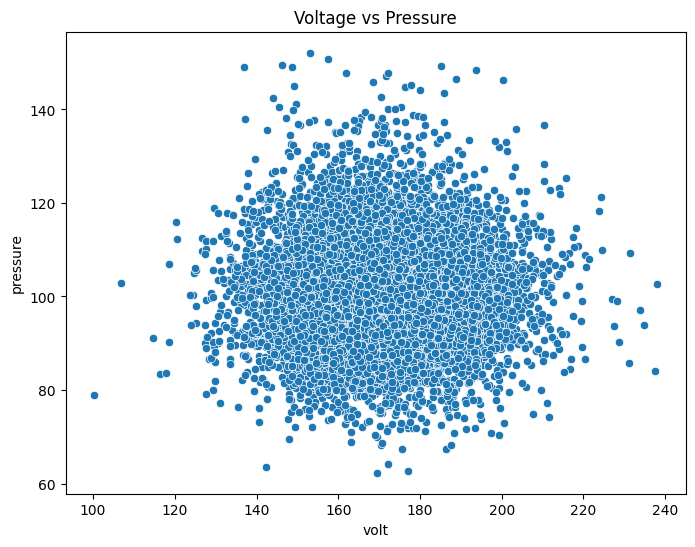

In [ ]:
sample = telemetry.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample,
    x='volt',
    y='pressure'
)

plt.title("Voltage vs Pressure")

plt.show()

* Relationship between voltage and pressure appears weak/moderate.
* No strong linear pattern is observed.

## 9.2 Voltage vs Vibration

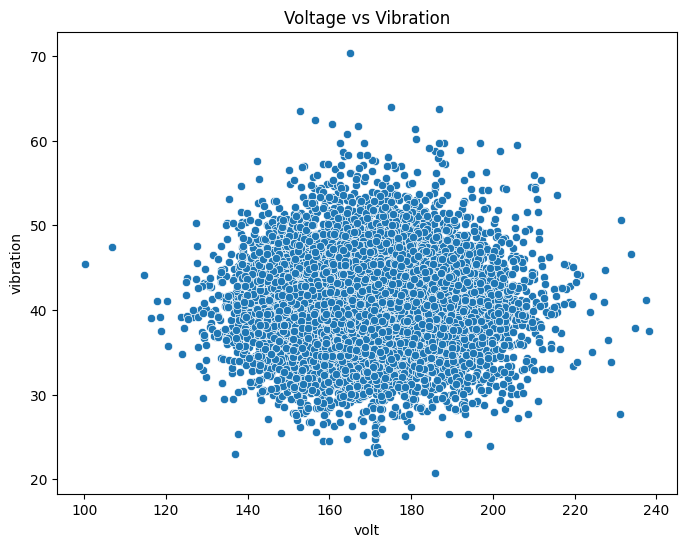

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample,
    x='volt',
    y='vibration'
)

plt.title("Voltage vs Vibration")

plt.show()

* Some high voltage observations are associated with increased vibration.
* Overall relationship remains moderate.

## 9.3 Pressure vs Vibration

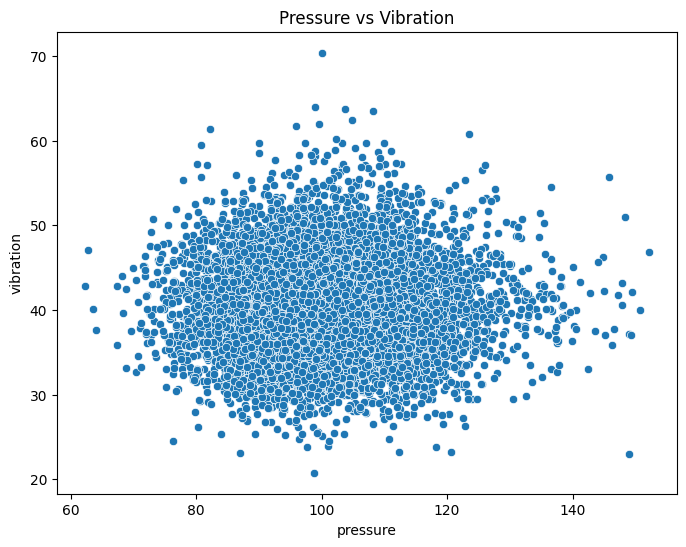

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample,
    x='pressure',
    y='vibration'
)

plt.title("Pressure vs Vibration")

plt.show()

* Higher pressure readings occasionally correspond with higher vibration.
* Several clusters of operating conditions are visible.

## 9.4 Rotation vs Vibration

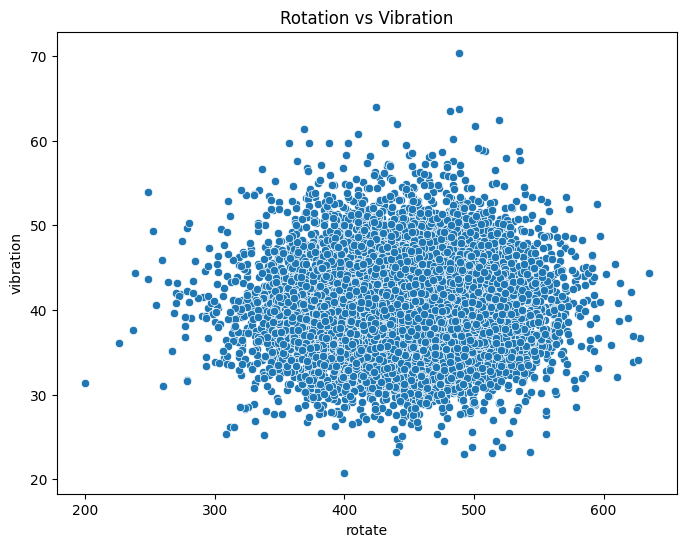

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample,
    x='rotate',
    y='vibration'
)

plt.title("Rotation vs Vibration")

plt.show()

* Machines operating at higher rotational speeds tend to show increased vibration.
* Relationship is more visible compared to other sensor pairs.

# 10 ) Correlation Analysis
## 10.1 Correlation Matrix

In [ ]:
corr_matrix = telemetry[
    [
        'volt',
        'rotate',
        'pressure',
        'vibration'
    ]
].corr()

corr_matrix

,volt,rotate,pressure,vibration
volt,1.000000,-0.001511,0.001652,0.002390
rotate,-0.001511,1.000000,-0.000688,-0.003056
pressure,0.001652,-0.000688,1.000000,0.001395
vibration,0.002390,-0.003056,0.001395,1.000000



* Sensor variables show low to moderate correlation.
* No severe multicollinearity exists.

## 10.2 Correlation Heatmap

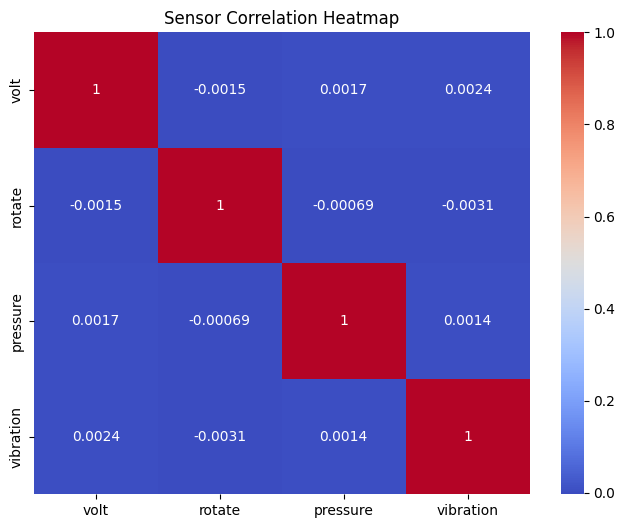

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Sensor Correlation Heatmap")

plt.show()


* Correlation strengths vary among sensors.
* Most relationships are weak to moderate.

# 11 ) Distribution Comparison Analysis

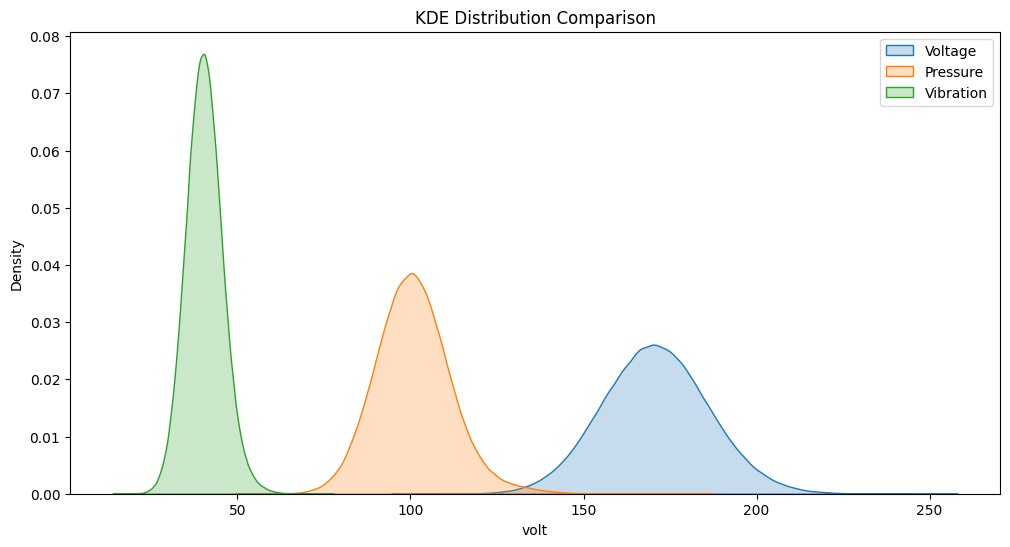

In [ ]:
plt.figure(figsize=(12,6))

sns.kdeplot(
    telemetry['volt'],
    label='Voltage',
    fill=True
)

sns.kdeplot(
    telemetry['pressure'],
    label='Pressure',
    fill=True
)

sns.kdeplot(
    telemetry['vibration'],
    label='Vibration',
    fill=True
)

plt.legend()

plt.title("KDE Distribution Comparison")

plt.show()


* Sensor distributions differ in shape and spread.
* Certain sensors exhibit higher variability.

* Different sensors capture different operational aspects.
* Feature scaling will be required during preprocessing.